In [1]:
import pandas as pd

In [2]:
df = pd.read_excel(r'C:\Users\DELL\Downloads\processed_sales_data.xlsx')

In [3]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
#Sales Statistics
print("Mean TotalPrice",df['TotalPrice'].mean())

Mean TotalPrice 1053.9683


In [5]:
print("Median TotalPrice",df['TotalPrice'].median())
print("Max TotalPrice",df['TotalPrice'].max())
print("Max TotalPrice",df['TotalPrice'].min())

Median TotalPrice 823.615
Max TotalPrice 3456.4
Max TotalPrice 11.39


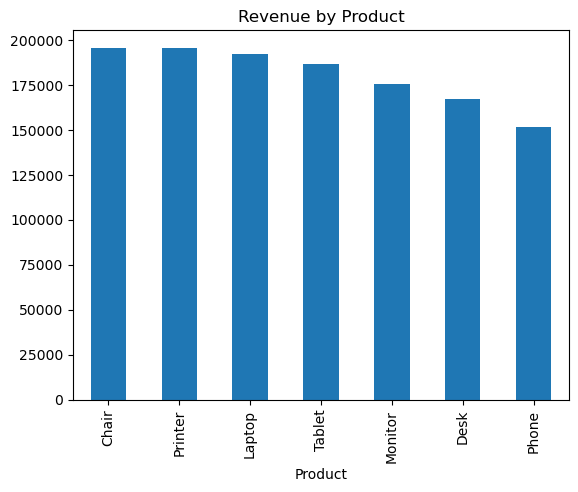

In [8]:
#Product Performance
import matplotlib.pyplot as plt
product_sales = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

product_sales.plot(kind='bar')
plt.title("Revenue by Product")
plt.show()

Order Status Analysis


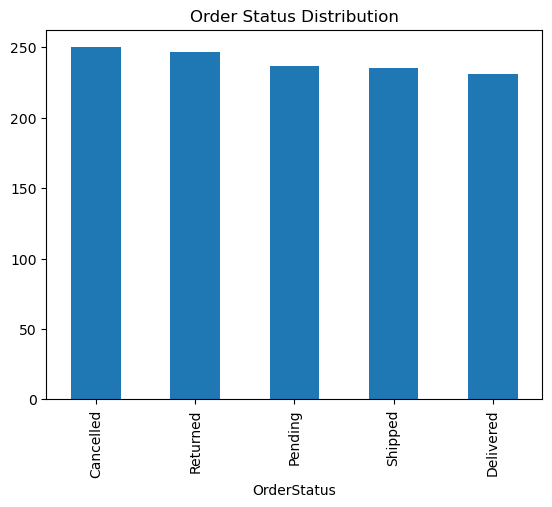

In [9]:
#Order Status Analysis
print("Order Status Analysis")
df['OrderStatus'].value_counts().plot(kind='bar')
plt.title("Order Status Distribution")
plt.show()

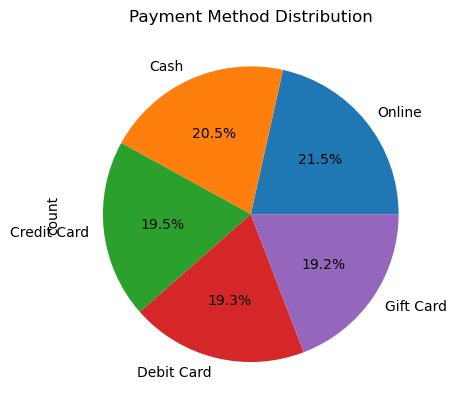

In [10]:
#Payment Method Analysis
df['PaymentMethod'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.show()

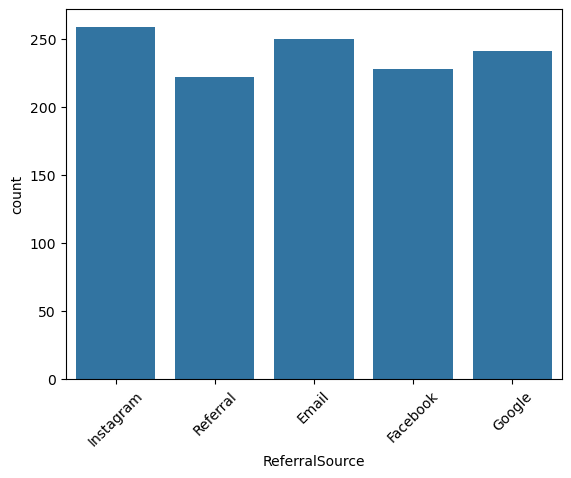

In [13]:
#Referal source Analysis
import seaborn as sns
sns.countplot(data=df, x='ReferralSource')
plt.xticks(rotation=45)
plt.show()

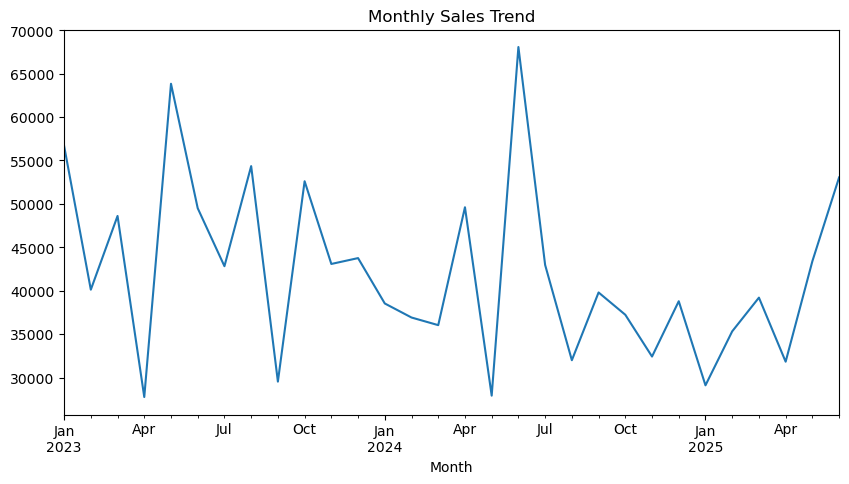

In [14]:
#Montly sales Trend
df['Month'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['TotalPrice'].sum()

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.show()

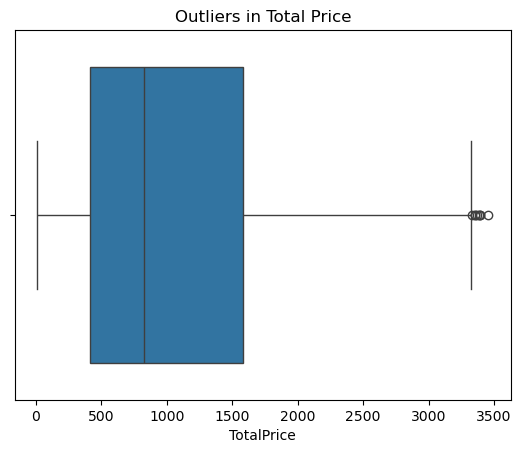

In [15]:
#Outliers Detection
sns.boxplot(x=df['TotalPrice'])
plt.title("Outliers in Total Price")
plt.show()

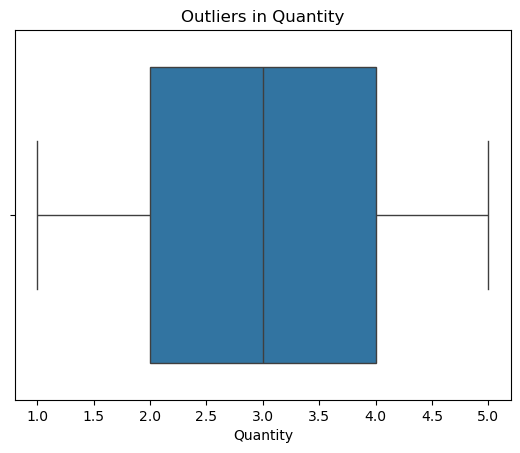

In [16]:
sns.boxplot(x=df['Quantity'])
plt.title("Outliers in Quantity")
plt.show()

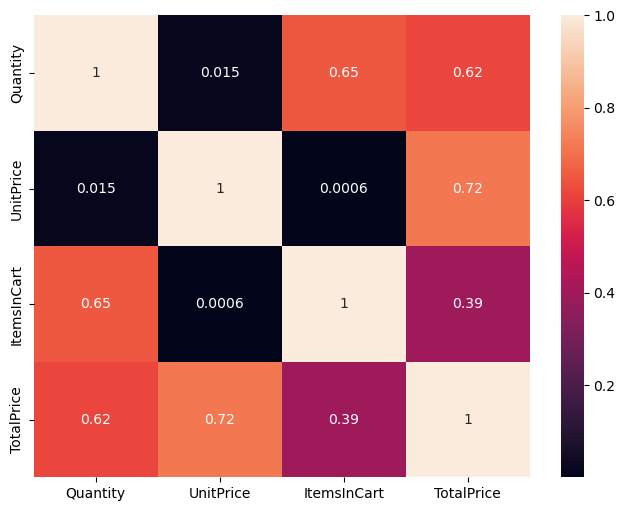

In [18]:
#Correlation Analysis
corr = df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.show()

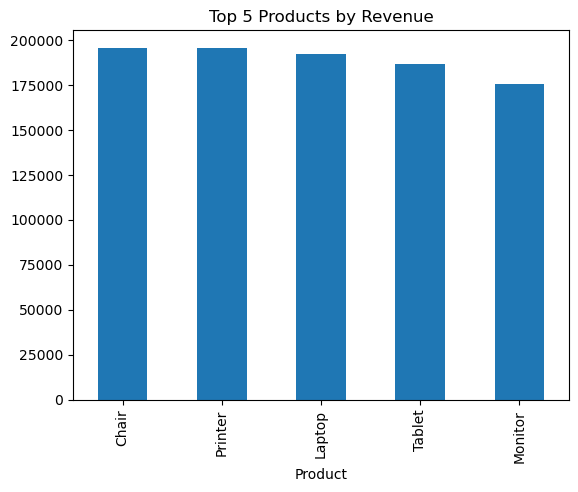

In [20]:
#Top 5 products
top5 = df.groupby('Product')['TotalPrice'].sum().nlargest(5)

top5.plot(kind='bar')
plt.title("Top 5 Products by Revenue")
plt.show()